Also include BGS tiles for this analysis

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.1/LRG/alltiles_LRGzinfo.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & (tmp['TARGETS']=='QSO+LRG'))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

1083682
58113
34868
34868
34702


In [4]:
# Catalog of all objects from all the different combinations (single exposures, deep coadds, etc.)
zbest1 = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.1/BGS_ANY/alltiles_BGS_ANYzinfo.fits'))
print(len(zbest1))

# Select deep coadds
mask = zbest1['subset']=='deep'
print(np.sum(mask))

# Select QSO+LRG tiles
mask &= zbest1['TARGETS']=='BGS+MWS'
print(np.sum(mask))

zbest1 = zbest1[mask]

print(len(zbest1))
print(len(np.unique(zbest1['TARGETID'])))

2441430
136551
129028
129028
128730


In [5]:
# Remove overlapping BGS targets
mask = np.in1d(zbest1['TARGETID'], zbest['TARGETID'])
print(np.sum(mask))
zbest1 = zbest1[~mask]

zbest = vstack([zbest, zbest1], join_type='exact')
print(len(zbest))

970
162926


In [6]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [7]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 137360 25566 0.1569178645520052
No data 137352 8 5.8241118229470004e-05


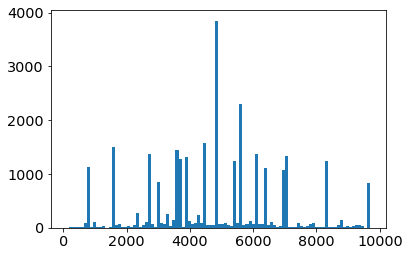

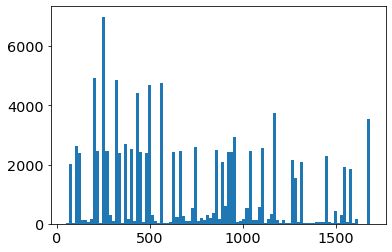

In [8]:
mask = zbest['TARGETS']=='QSO+LRG'
plt.hist(zbest['EFFTIME_DARK'][mask], 100)
plt.show()

mask = zbest['TARGETS']=='BGS+MWS'
plt.hist(zbest['EFFTIME_DARK'][mask], 100)
plt.show()

In [9]:
# # Require a minimum depth for the BGS and LRG+QSO tiles

mask1 = zbest['TARGETS']=='QSO+LRG'
mask1 &= zbest['EFFTIME_DARK']>2000

mask2 = zbest['TARGETS']=='BGS+MWS'
mask2 &= zbest['EFFTIME_DARK']>900

mask = mask1 | mask2
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

62769 0.4569937095928709


In [10]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# # Require a minimum depth for the deep coadd
# min_depth = 4000.
# mask = zbest['EFFTIME_DARK']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 62769 0 0.0
No data 62769 0 0.0
62769


In [11]:
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.0

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 57353 5416 0.9137153690516019
57353


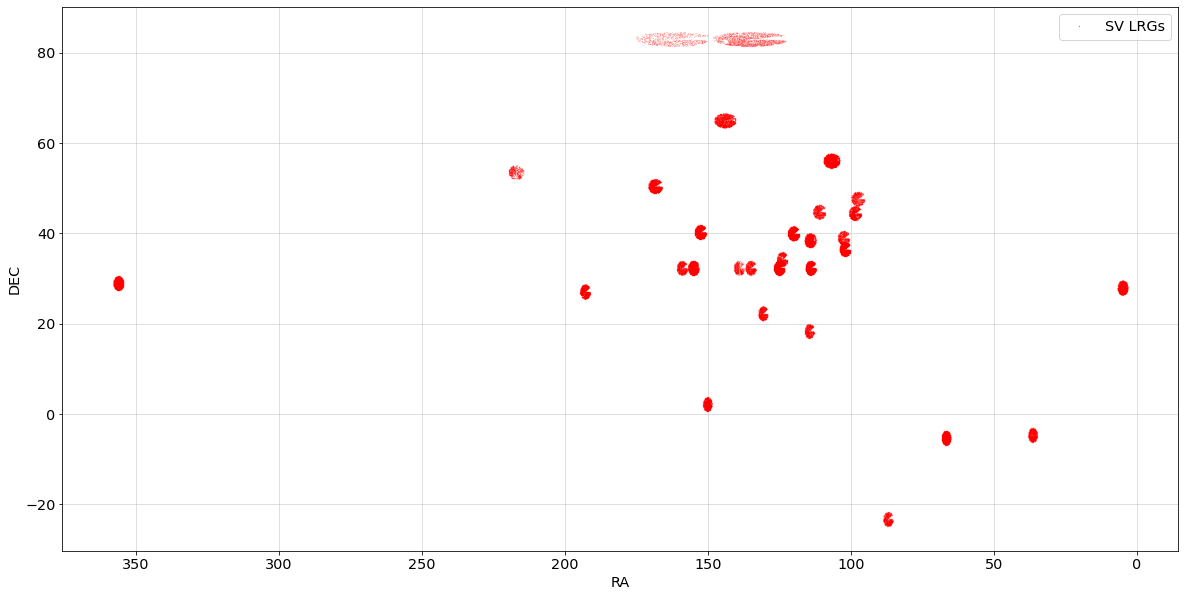

In [12]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [13]:
np.unique(zbest['TARGETS'], return_counts=True)

(<Column name='TARGETS' dtype='str7' length=2>
 BGS+MWS
 QSO+LRG,
 array([34903, 22450]))

__Add Galactic extinction columns from sweep catalogs (it might take a minute or two)__

In [14]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

zbest = join(zbest, ls, keys='TARGETID')

66
57353 57117


In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [ ]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [173]:
#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.22) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.47) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.17) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.43) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

8847
8932


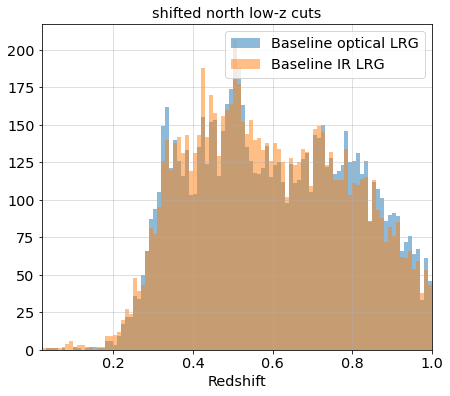

In [158]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt], bins=100, range=(0., 1.), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir], bins=100, range=(0., 1.), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

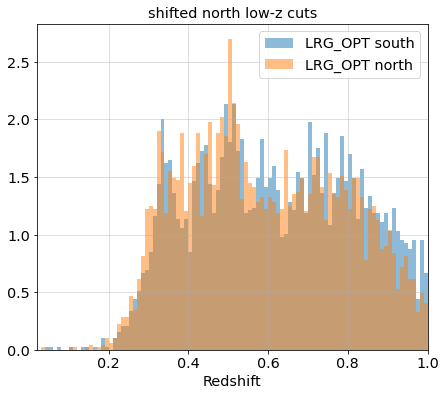

In [159]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt_south], bins=100, range=(0., 1.), label='LRG_OPT south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_opt_north], bins=100, range=(0., 1.), label='LRG_OPT north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

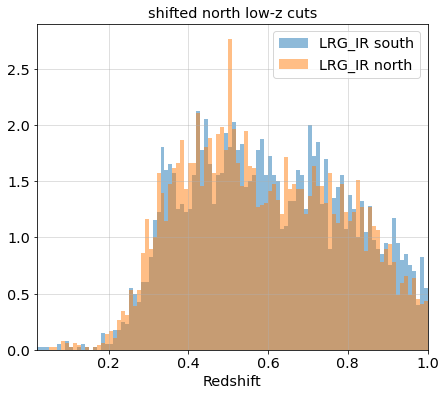

In [160]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_ir_south], bins=100, range=(0., 1.), label='LRG_IR south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_ir_north], bins=100, range=(0., 1.), label='LRG_IR north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

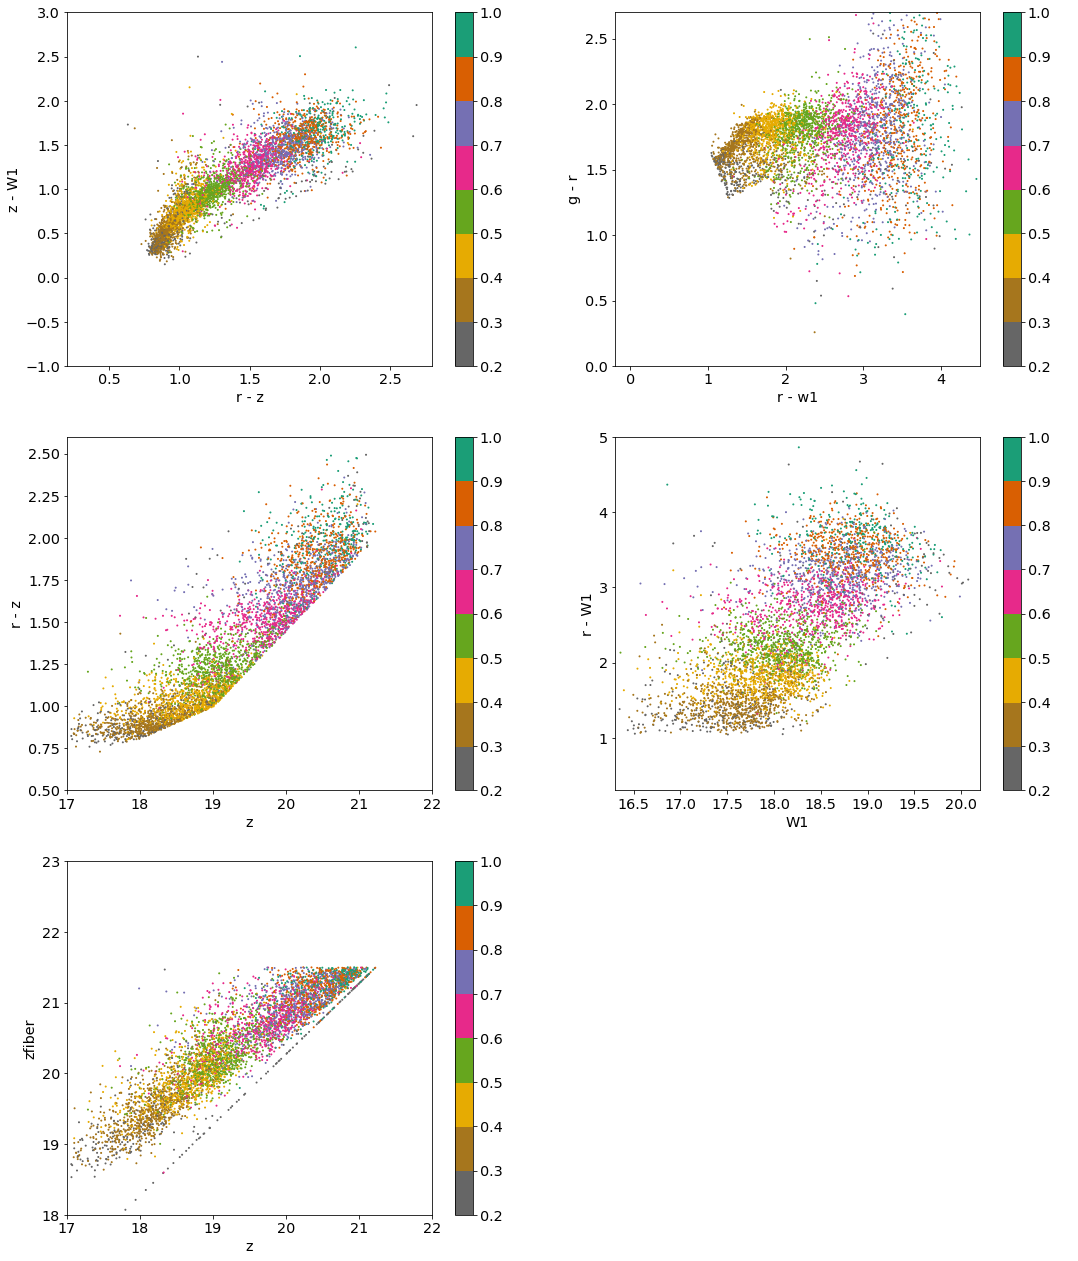

In [135]:
color_plot_3x2_simple(zbest[lrg_opt_north], color_col='Z', ms=1)

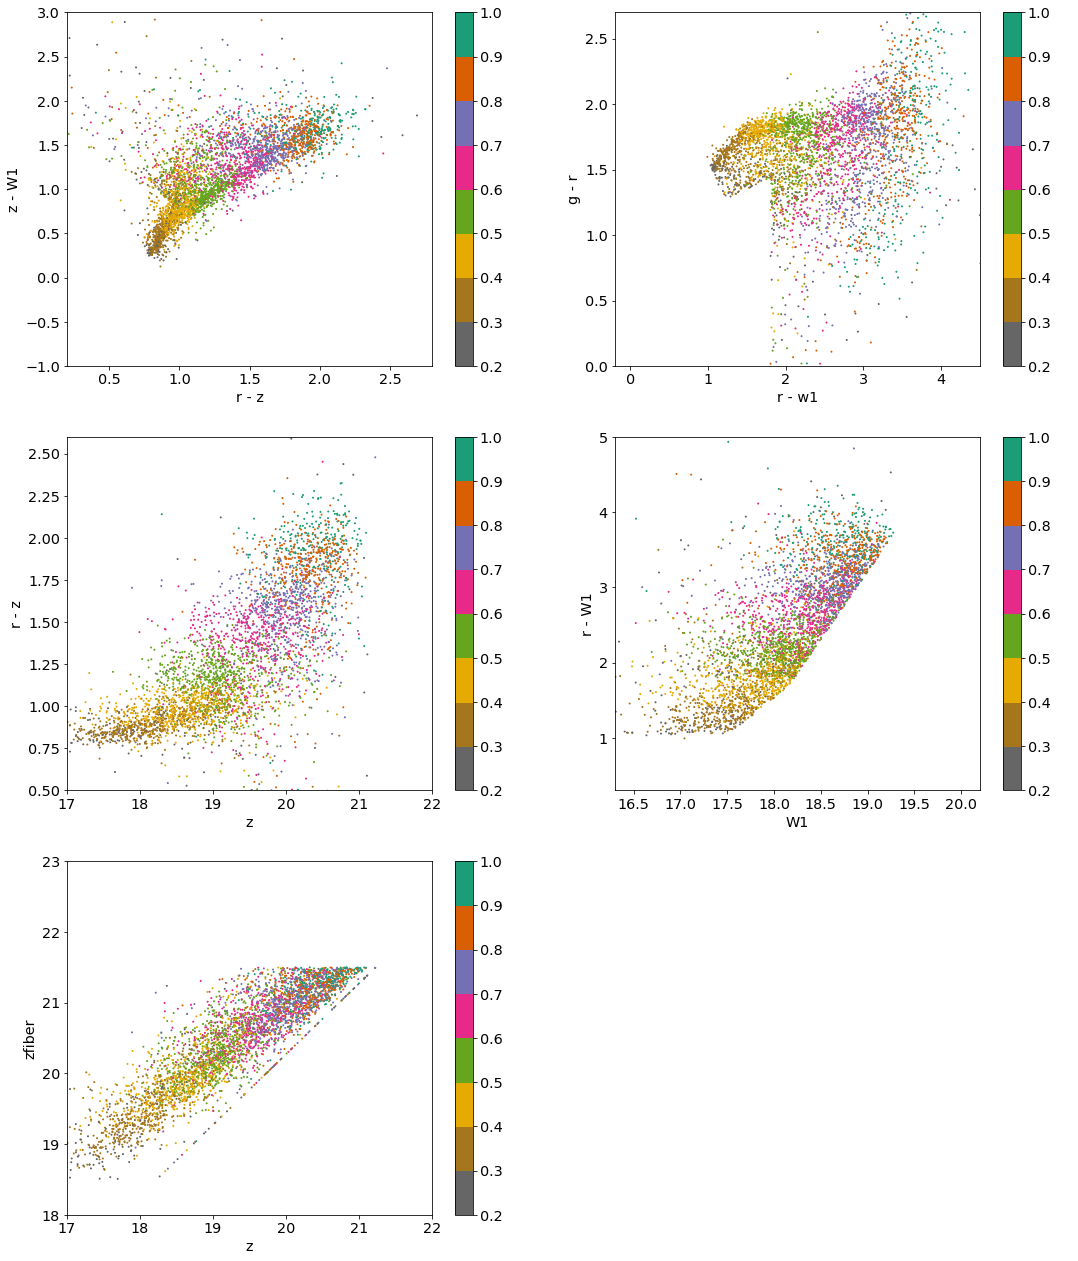

In [136]:
color_plot_3x2_simple(zbest[lrg_ir_south], color_col='Z', ms=1)

-----
## Only intercept shift

In [163]:
#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.22) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.18) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

8847
8643


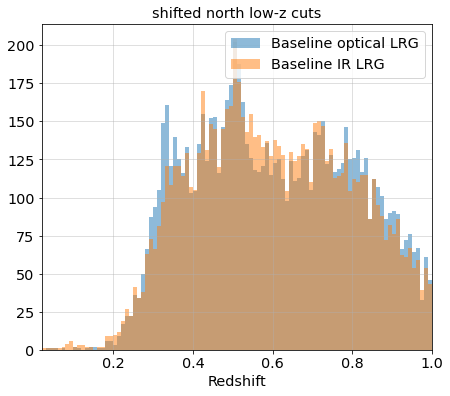

In [164]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt], bins=100, range=(0., 1.), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir], bins=100, range=(0., 1.), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

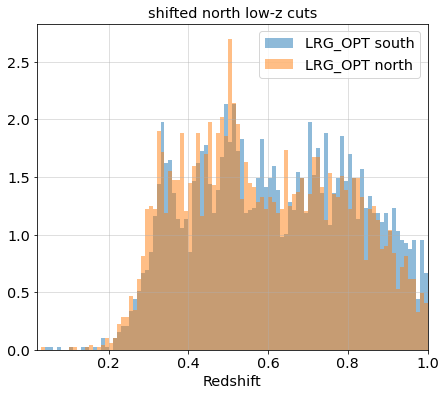

In [165]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt_south], bins=100, range=(0., 1.), label='LRG_OPT south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_opt_north], bins=100, range=(0., 1.), label='LRG_OPT north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

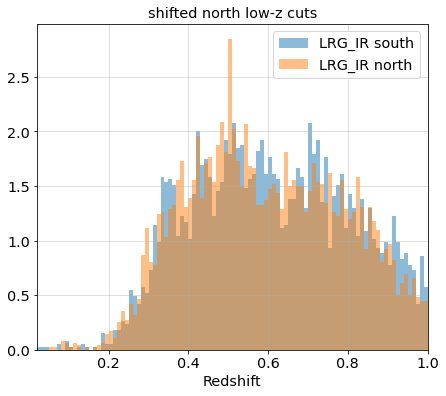

In [166]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_ir_south], bins=100, range=(0., 1.), label='LRG_IR south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_ir_north], bins=100, range=(0., 1.), label='LRG_IR north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

-----
## low-z intercept shift + IR low-z sliding cut intercept shift

In [172]:
# Changelog:
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing its density), to account for the north vs south difference
# - Shift IR low-z sliding cut intercept by 0.05 (increasing its density), to make its low-z N(z) closer to the optical version

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.22) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.42) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.18) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.38) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

8847
8842


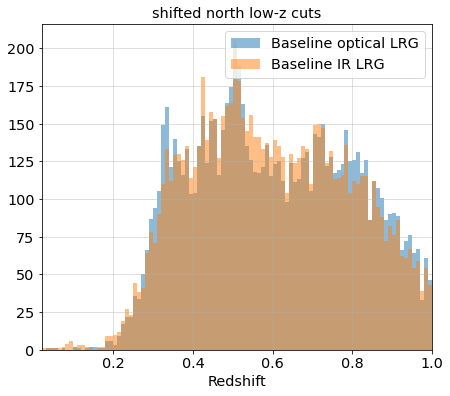

In [168]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt], bins=100, range=(0., 1.), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir], bins=100, range=(0., 1.), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

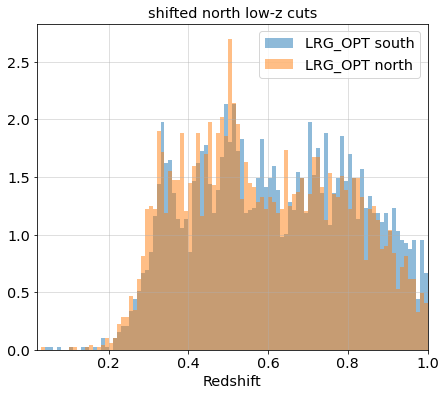

In [165]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt_south], bins=100, range=(0., 1.), label='LRG_OPT south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_opt_north], bins=100, range=(0., 1.), label='LRG_OPT north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

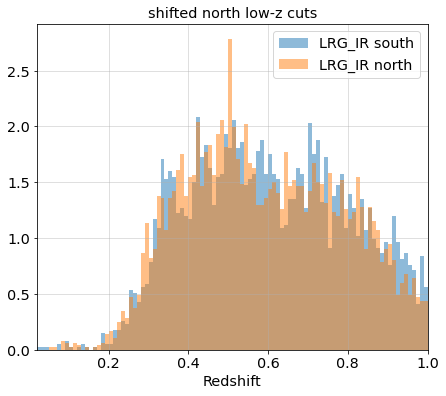

In [169]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_ir_south], bins=100, range=(0., 1.), label='LRG_IR south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_ir_north], bins=100, range=(0., 1.), label='LRG_IR north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('shifted north low-z cuts')
plt.show()

-----
## Previous version (same low-z cuts for north and south)

In [144]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<17)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.22) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<17)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.18) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (zbest['GAIA_PHOT_G_MEAN_MAG']!=0) & (zbest['GAIA_PHOT_G_MEAN_MAG']<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

8919
8679


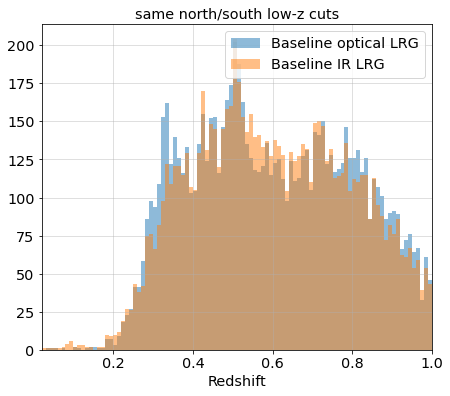

In [150]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt], bins=100, range=(0., 1.), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir], bins=100, range=(0., 1.), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('same north/south low-z cuts')
plt.show()

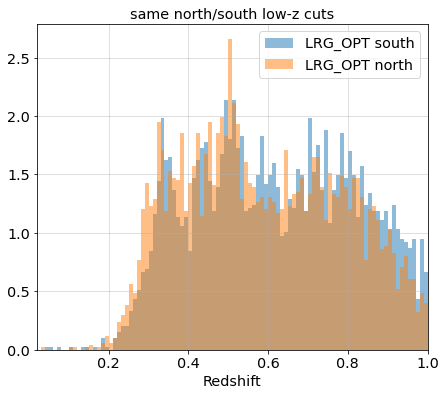

In [148]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_opt_south], bins=100, range=(0., 1.), label='LRG_OPT south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_opt_north], bins=100, range=(0., 1.), label='LRG_OPT north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('same north/south low-z cuts')
plt.show()

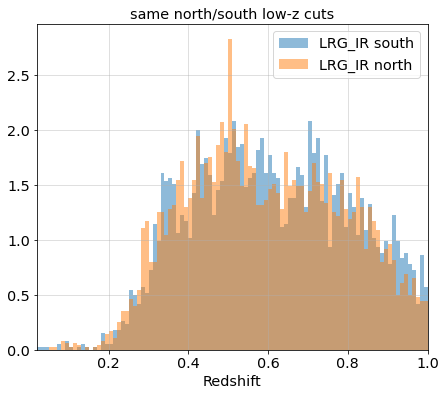

In [149]:
plt.figure(figsize=(7, 6))
plt.hist(zbest['Z'][lrg_ir_south], bins=100, range=(0., 1.), label='LRG_IR south', alpha=0.5, density=True)
plt.hist(zbest['Z'][lrg_ir_north], bins=100, range=(0., 1.), label='LRG_IR north', alpha=0.5, density=True)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.xlim(0.02, 1.0)
plt.title('same north/south low-z cuts')
plt.show()